# Part_3_Input_Perturbation

### 1. Setup & Sentence Definitions

In [1]:
# PART 3 — Model Robustness via Input Perturbation
# This notebook evaluates how robust your emotion classifier is by removing least relevant tokens
# and tracking how the prediction confidence changes.

from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# Load model and tokenizer from local CamemBERT directory
model_path = "./camembert_model_6"
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)
model.eval()

# 18 hand-picked sentences (3 per emotion)
sentences_by_emotion = {
    "happiness": [
        "Il est super!Je veux dire que nous passons un si bon moment ensemble!Il est tellement drôle et tellement doux, et je ne suis pas du tout attiré par lui !!",
        "Les Recaptchas d'aujourd'hui étaient amusants.",
        "Oh, c'est super."
    ],
    "sadness": [
        "Je à peux tout simplement pas comprendre ce vaudou ne capuche d'un autre monde.",
        "Ces moments heureux me manquent.",
        "Je juste triste quand je vois des gens commenter des articles et des vidéos lui qu'ils pensent qu'il sur la."
    ],
    "anger": [
        "Les mecs nus dans le magazine Playgirl ! C'était comme le magazine Playboy, mais avec des hommes nus.",
        "Si ce genre de gars sont votre seule option, vous pourriez être mieux hors célibataire…",
        "Je veux récupérer mon putain de gâteau."
    ],
    "surprise": [
        "Je ne peux pas croire que cela vient d'arriver !",
        "Dans un autre environnement ?",
        "Comment ça s'est passé en première page ?"
    ],
    "fear": [
        "Euhhh, je ne pense pas que tu vas aimer ça.",
        "Aw, peux-tu dire ça?Je ne peux même pas demander Marcel de manger tapis de bain. vais-je élever un enfant?",
        "J'ai peur de devoir suivre ce qu'il a dit il y a une heure."
    ],
    "disgust": [
        "Comment quelqu'un peut-il supporter ça ?",
        "La Ligue veut qu'une équipe de DE LA travaille enfin si mal.",
        "Je me sens malade rien qu'en regardant ça."
    ]
}

### 2. Gradient × Input Method for Relevance

In [2]:
# Compute token relevance using Gradient × Input
def gradient_x_input(model, inputs):
    inputs_embeds = model.get_input_embeddings()(inputs.input_ids)
    inputs_embeds = inputs_embeds.clone().detach().requires_grad_(True)

    outputs = model(inputs_embeds=inputs_embeds, attention_mask=inputs.attention_mask)
    outputs.logits[:, outputs.logits.argmax()].backward()

    if inputs_embeds.grad is None:
        raise RuntimeError("No gradients computed. Check model inputs.")
    
    return inputs_embeds.grad * inputs_embeds

### 3. Perturbation Function (Token Removal)

In [3]:
# Perturb input by removing (masking with [PAD]) least relevant tokens
def perturb_input_and_evaluate(model, tokenizer, text, relevance_scores, perturb_type='remove'):
    tokens = tokenizer.tokenize(text)

    if perturb_type == 'remove':
        sorted_indices = torch.argsort(relevance_scores[0].norm(dim=-1), descending=False)
    else:
        sorted_indices = torch.argsort(relevance_scores[0].norm(dim=-1), descending=True)

    sorted_indices = sorted_indices.tolist()
    perturbed_texts = []

    for i in range(1, len(tokens) + 1):
        temp_tokens = tokens[:]
        for idx in sorted_indices[:i]:
            if idx < len(temp_tokens):
                temp_tokens[idx] = '[PAD]'
        perturbed_texts.append(tokenizer.convert_tokens_to_string(temp_tokens))

    confidences = []
    for pert_text in perturbed_texts:
        pert_inputs = tokenizer(pert_text, return_tensors='pt')
        with torch.no_grad():
            logits = model(**pert_inputs).logits
            confidence = logits.softmax(dim=-1).max().item()
            confidences.append(confidence)

    return confidences

### 4. Run Perturbation and Plot Results

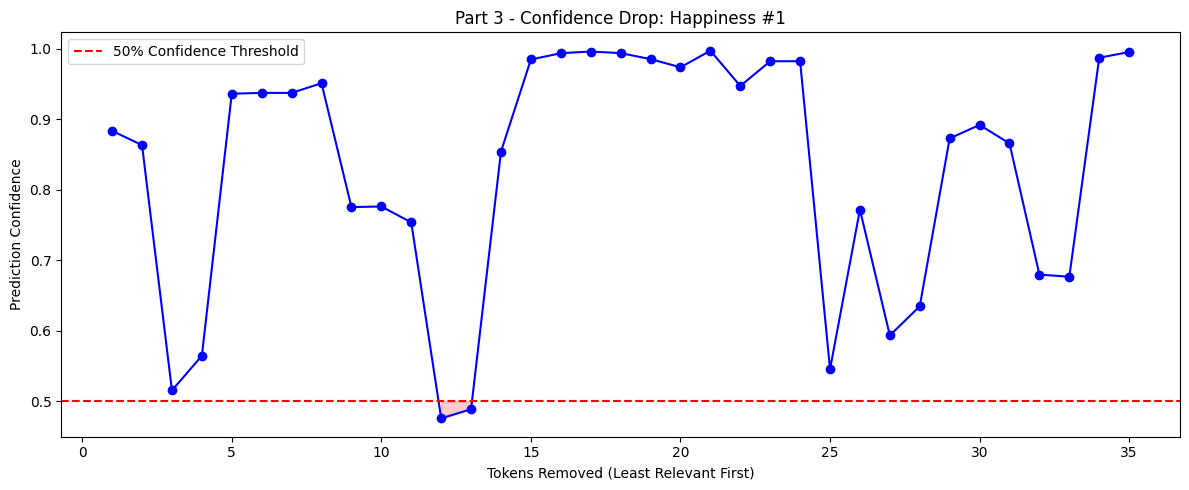

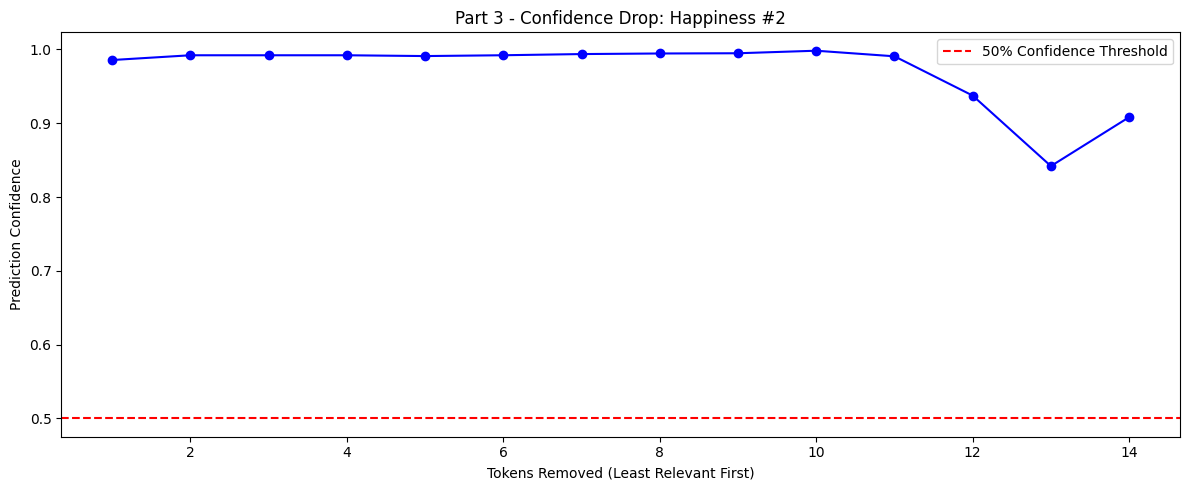

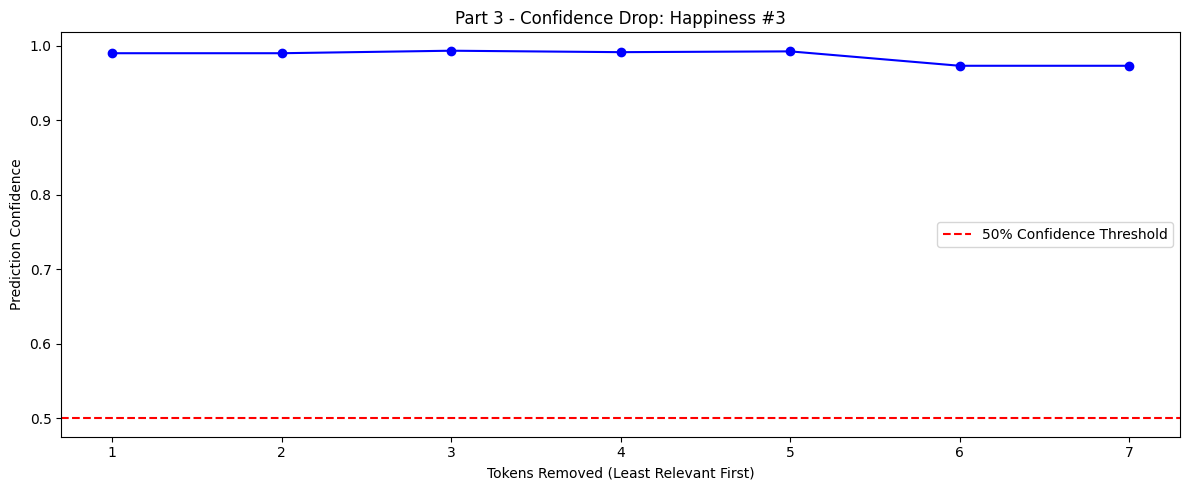

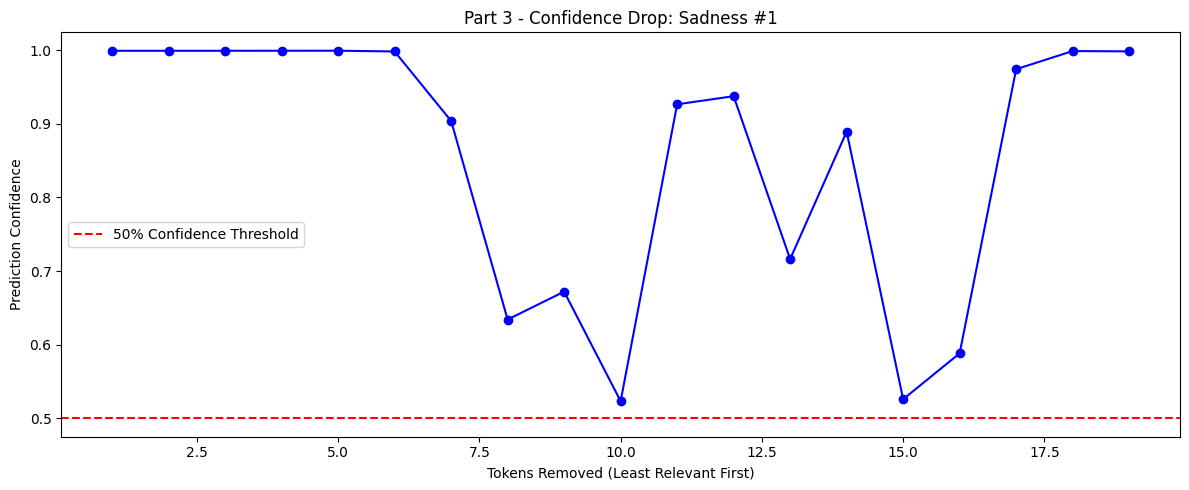

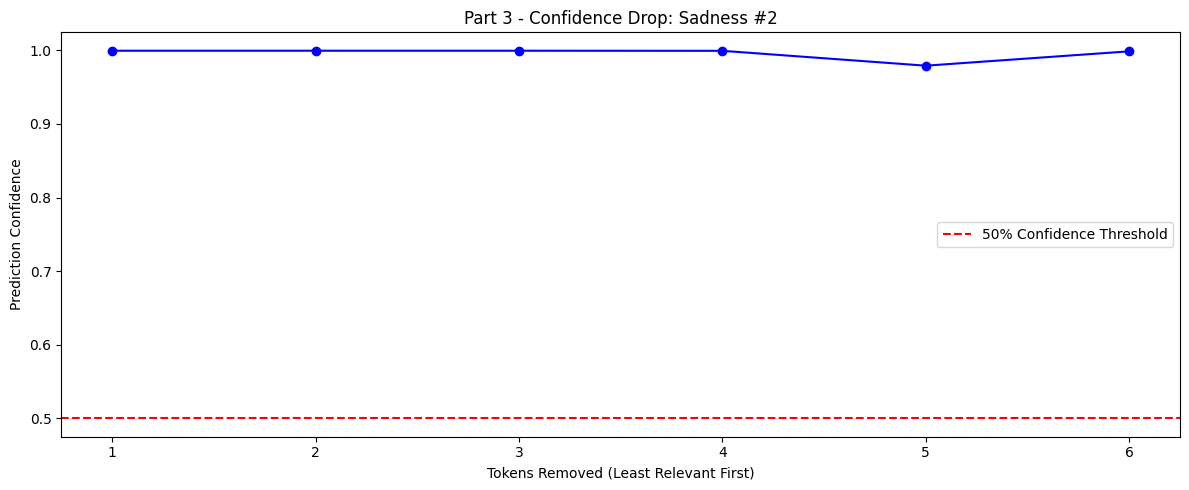

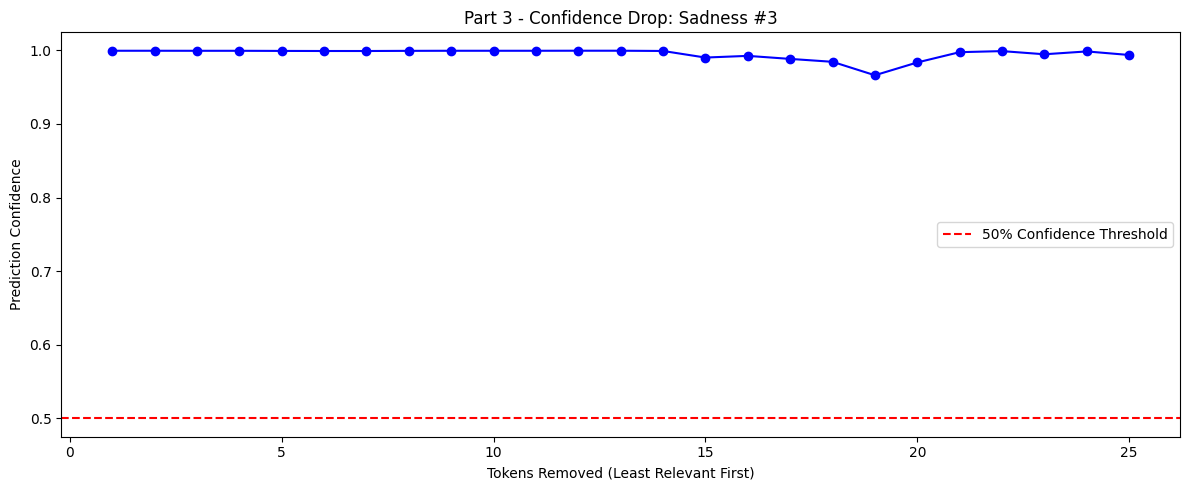

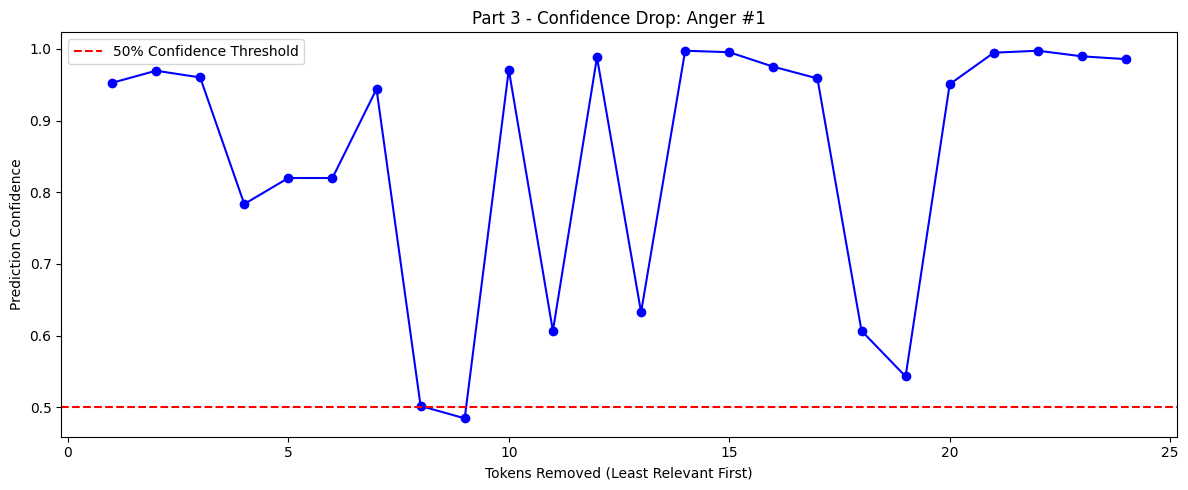

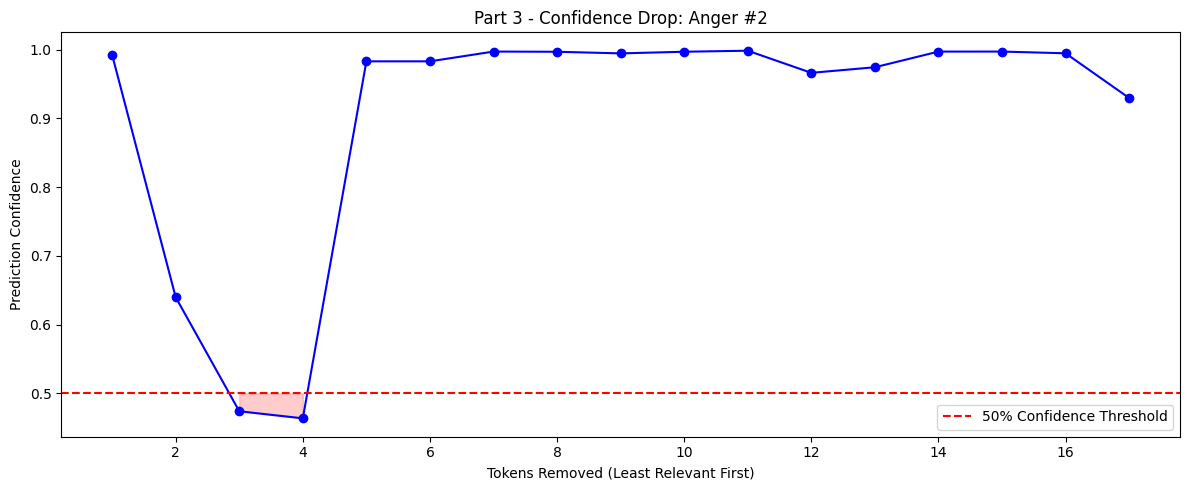

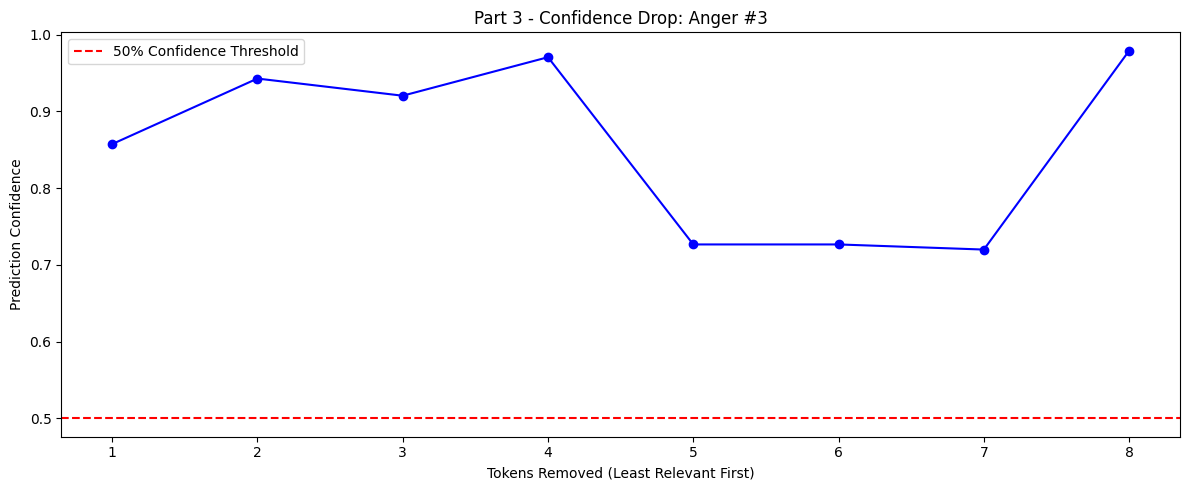

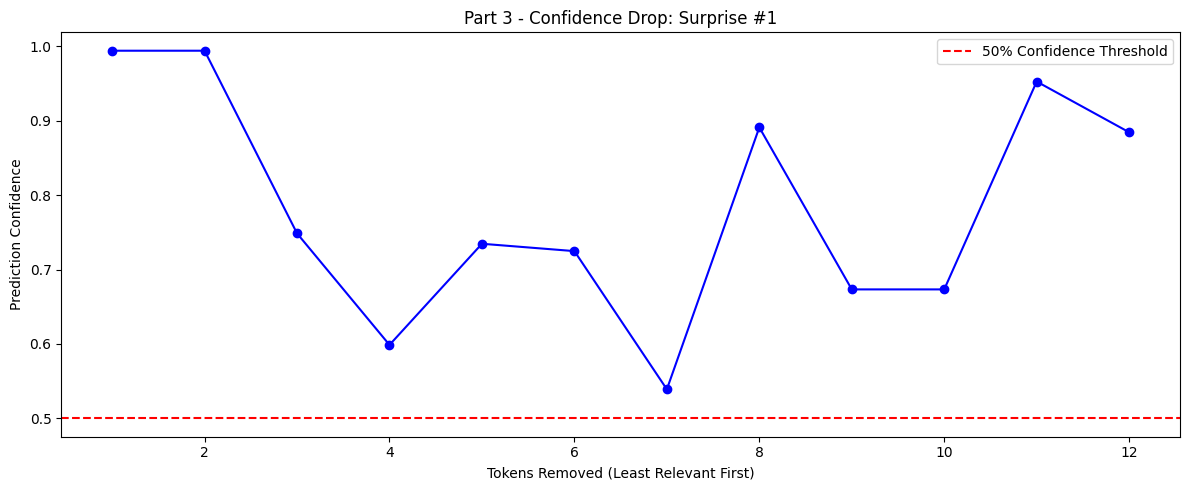

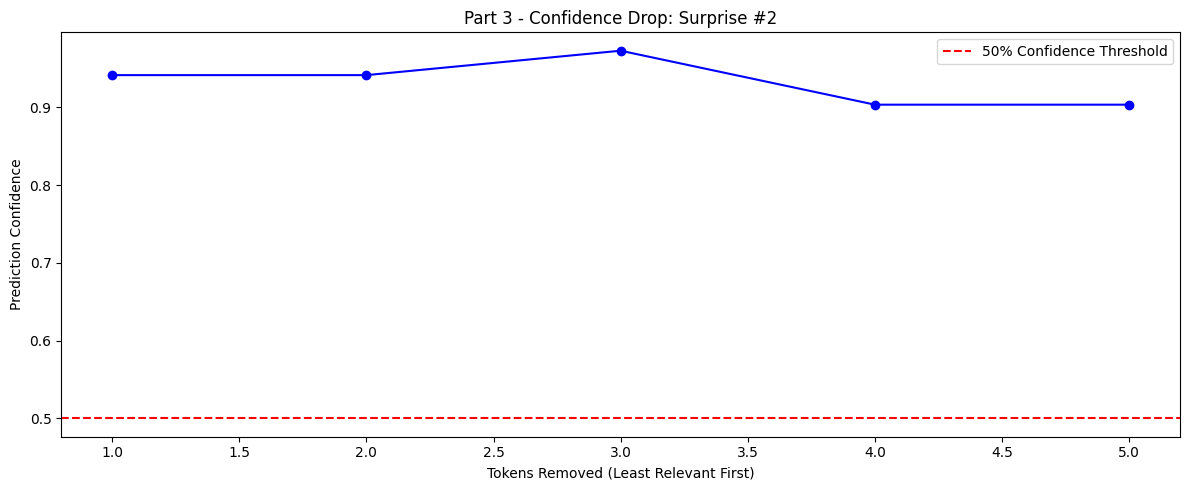

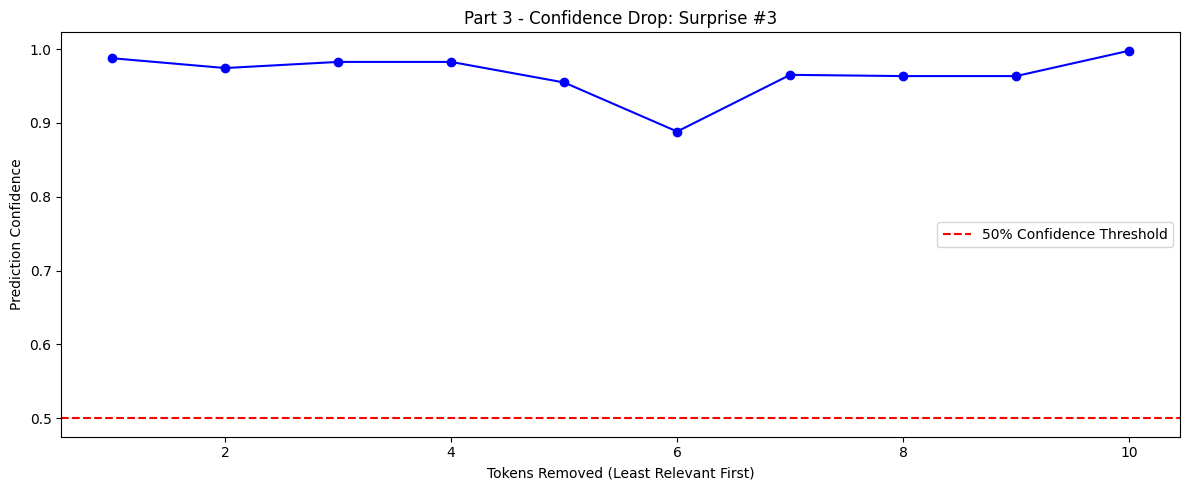

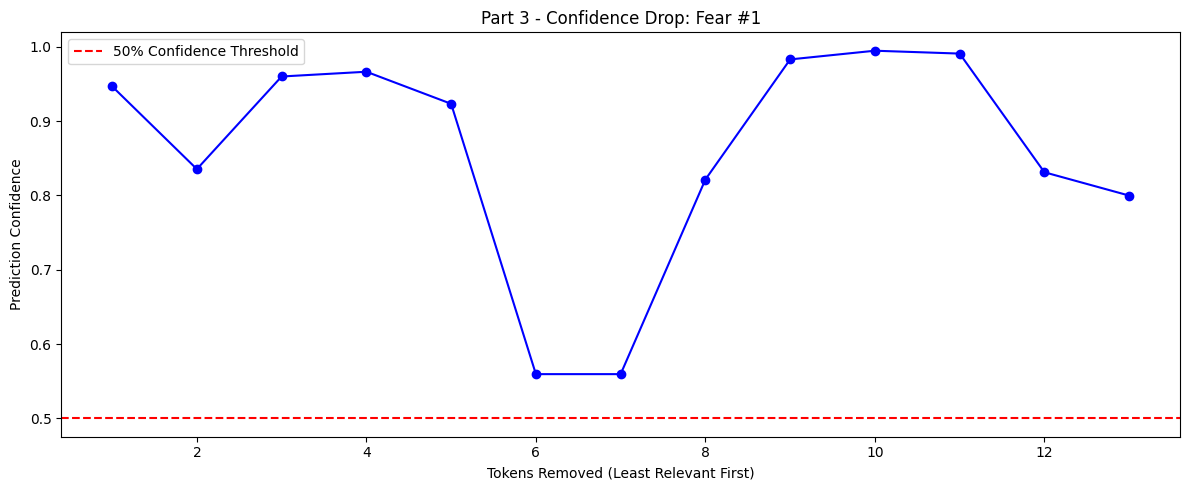

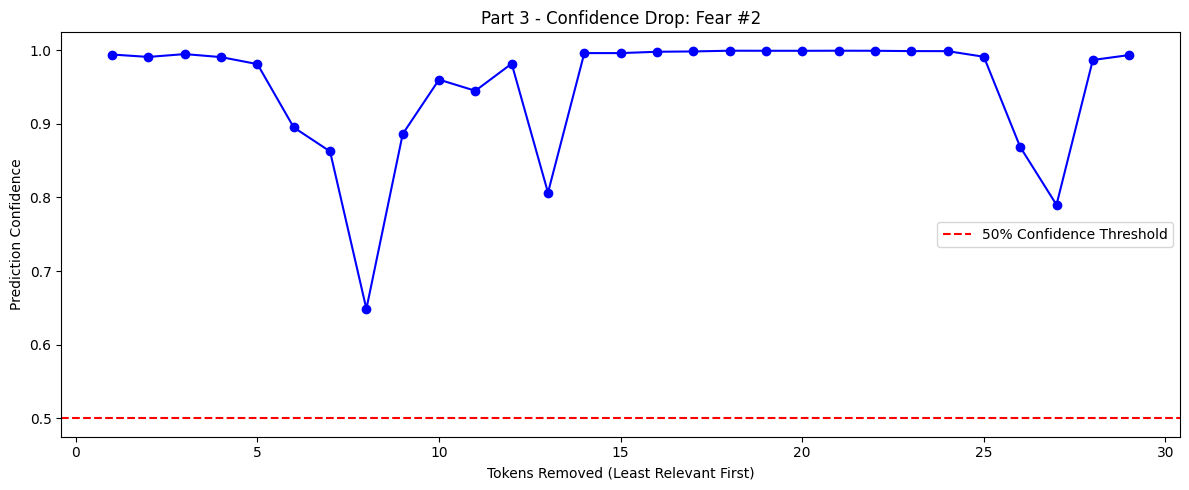

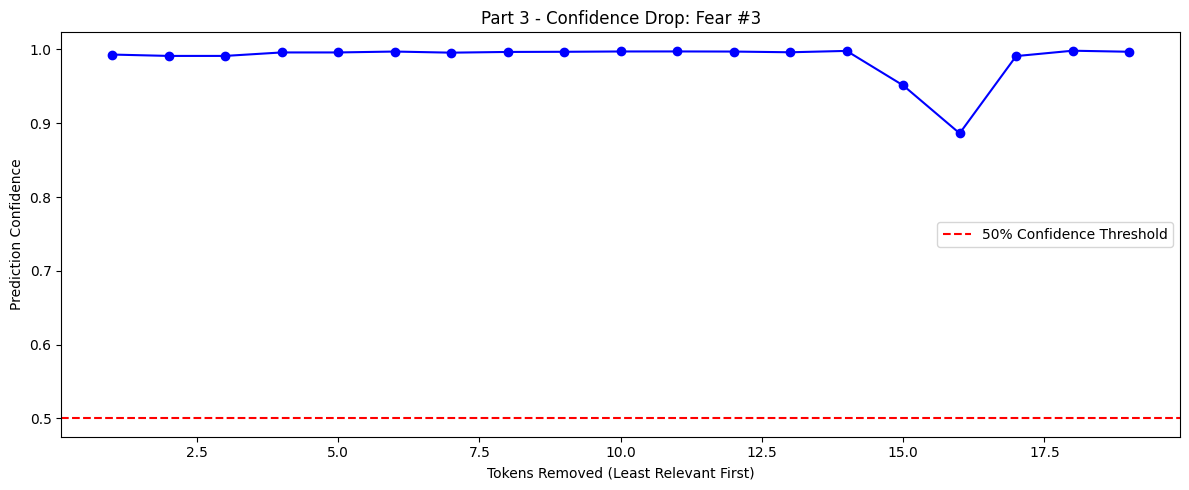

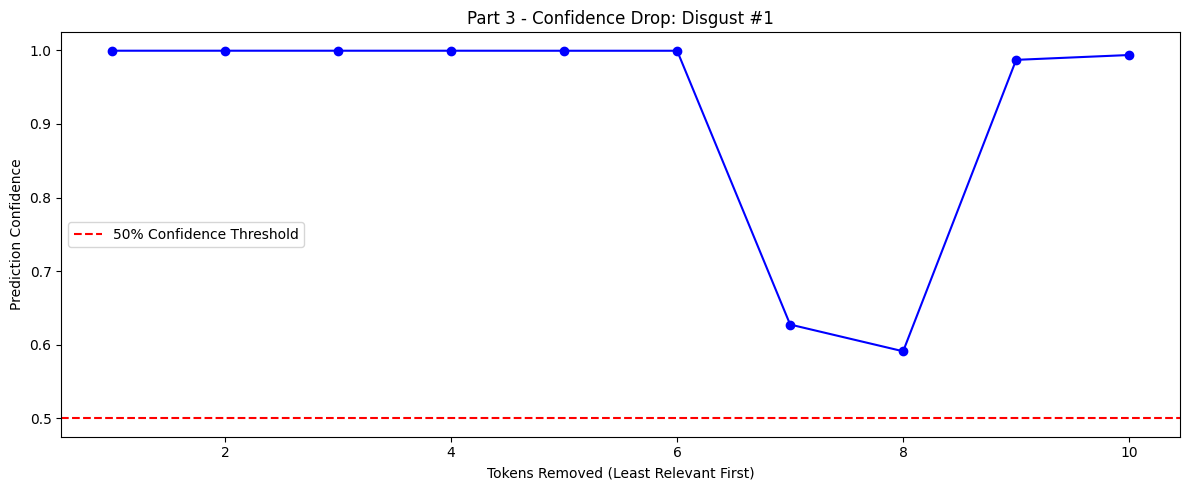

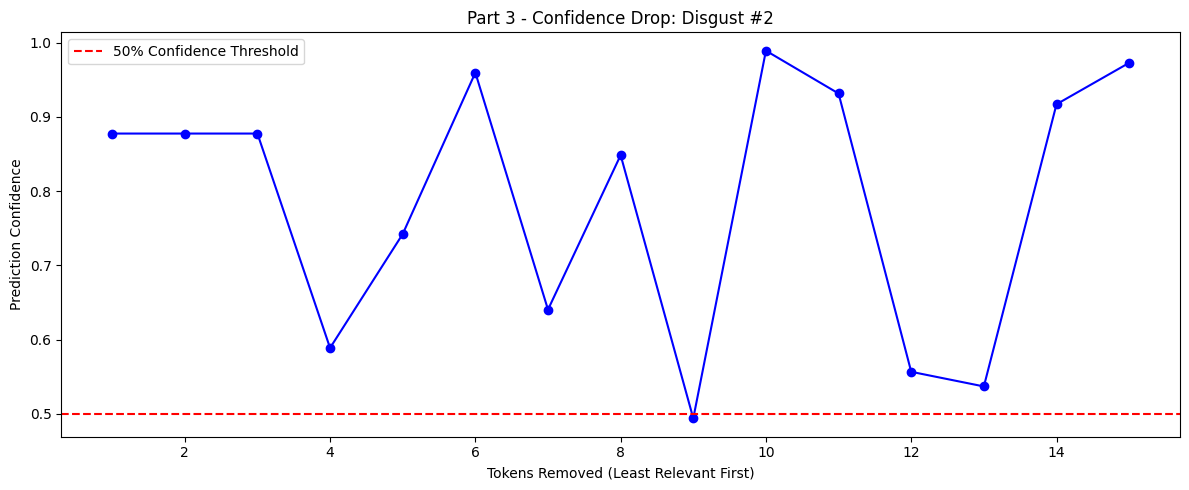

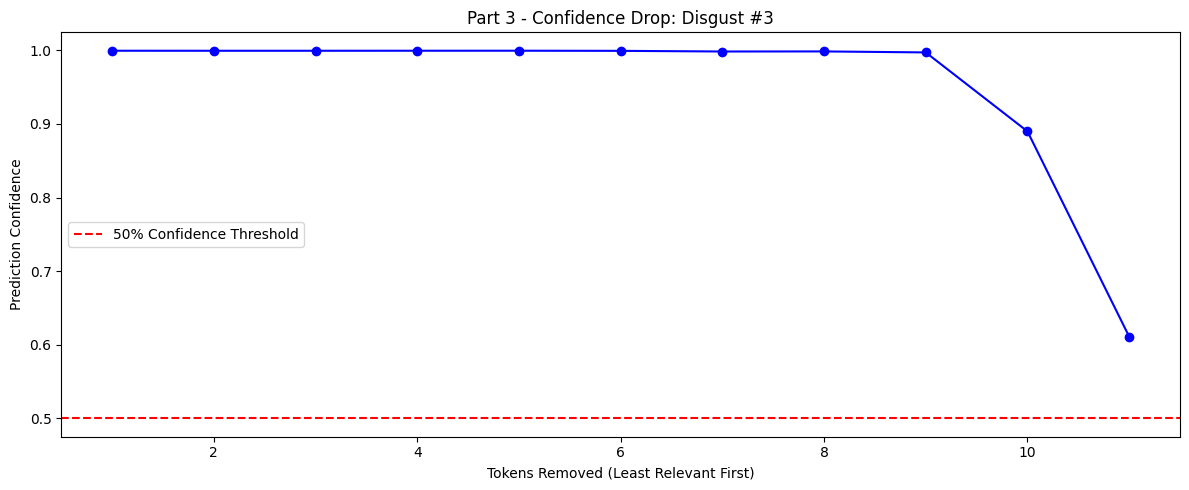

In [4]:
# Create output directory for Part 3 if not exists
output_dir = "outputs/part3_perturbation"
os.makedirs(output_dir, exist_ok=True)

# Evaluate model confidence drop after removing least relevant tokens
for emotion, sentence_list in sentences_by_emotion.items():
    for idx, sentence in enumerate(sentence_list):
        inputs = tokenizer(sentence, return_tensors='pt')
        relevance_scores = gradient_x_input(model, inputs)
        tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])

        # Get model confidence as tokens are removed
        confidences = perturb_input_and_evaluate(model, tokenizer, sentence, relevance_scores)

        min_len = min(len(tokens), len(confidences))
        confidences = np.array(confidences)

        # Plot the change in confidence
        plt.figure(figsize=(12, 5))
        plt.plot(range(1, min_len + 1), confidences[:min_len], marker='o', color='blue')
        plt.axhline(y=0.5, color='red', linestyle='--', label="50% Confidence Threshold")
        plt.fill_between(range(1, min_len + 1), confidences[:min_len], 0.5,
                         where=(confidences[:min_len] < 0.5), color='red', alpha=0.2)
        plt.title(f"Part 3 - Confidence Drop: {emotion.capitalize()} #{idx+1}")
        plt.xlabel("Tokens Removed (Least Relevant First)")
        plt.ylabel("Prediction Confidence")
        plt.legend()
        plt.tight_layout()

        plt.show()
        plt.savefig(f"{output_dir}/{emotion}_{idx+1}.png")
        plt.close()